In [1]:
#!pip install tensorflow

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import cifar10

In [3]:
learning_rate = 0.01

epochs = 300

batch_size = 64

In [4]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

indices = np.random.permutation(len(x_train))
x_train = x_train[indices[:10000]]
y_train = y_train[indices[:10000]]

indices = np.random.permutation(len(x_test))
x_test = x_test[indices[:2000]]
y_test = y_test[indices[:2000]]

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(len(x_train), 3072)

x_test = x_test.reshape(len(x_test), 3072)

In [5]:
def one_hot(y, classes):

    result = np.zeros((len(y), classes))

    for i in range(len(y)):

        result[i][y[i]] = 1

    return result

y_train_encoded = one_hot(y_train.flatten(), 10)

y_test_encoded = one_hot(y_test.flatten(), 10)

In [6]:
def relu(x):

    return np.maximum(0, x)

def relu_derivative(x):

    return (x > 0).astype(float)


In [7]:
def softmax(x):

    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))

    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

In [8]:
def forward(x, weights, biases):

    activations = [x]

    zs = []

    a = x

    for i in range(len(weights) - 1):

        z = np.dot(a, weights[i]) + biases[i]

        a = relu(z)

        zs.append(z)

        activations.append(a)

    z = np.dot(a, weights[-1]) + biases[-1]

    a = softmax(z)

    zs.append(z)

    activations.append(a)

    return activations, zs

In [9]:
#cross entropy loss
def compute_loss(y_true, y_pred):

    epsilon = 1e-10

    loss = -np.mean(np.sum(y_true * np.log(y_pred + epsilon), axis=1))

    return loss

In [10]:
def backward(activations, zs, y_true, weights, biases):

    m = y_true.shape[0]

    weight_gradients = []

    bias_gradients = []

    dz = activations[-1] - y_true

    for i in reversed(range(len(weights))):

        dw = np.dot(activations[i].T, dz) / m

        db = np.sum(dz, axis=0, keepdims=True) / m

        weight_gradients.insert(0, dw)

        bias_gradients.insert(0, db)

        if i > 0:

            da = np.dot(dz, weights[i].T)

            dz = da * relu_derivative(zs[i - 1])

    for i in range(len(weights)):

        weights[i] -= (learning_rate * weight_gradients[i])

        biases[i] -= (learning_rate * bias_gradients[i])

In [11]:
def accuracy(x, y, weights, biases):

    activations, _ = forward(x, weights, biases)

    predictions = np.argmax(activations[-1], axis=1)

    labels = np.argmax(y, axis=1)

    acc = np.mean(predictions == labels)

    return acc * 100

In [12]:
def train_network(architecture):

    print("\n===================================")

    print(
        "ARCHITECTURE:",
        architecture
    )

    print("===================================")

    layers = architecture


    weights = []

    biases = []

    for i in range(len(layers) - 1):

        w = np.random.randn(layers[i], layers[i + 1]) * np.sqrt(2 / layers[i])

        b = np.zeros((1, layers[i + 1]))

        weights.append(w)

        biases.append(b)

    train_losses = []
    test_losses = []

    train_accuracies = []
    test_accuracies = []

    for epoch in range(epochs):

        indices = np.random.permutation(len(x_train))

        x_train_shuffled = x_train[indices]

        y_train_shuffled = y_train_encoded[indices]


        for i in range(0, len(x_train_shuffled), batch_size):

            x_batch = x_train_shuffled[i:i + batch_size]
            y_batch = y_train_shuffled[i:i + batch_size]

            activations, zs = forward(x_batch, weights, biases)
            backward(activations, zs, y_batch, weights, biases)

        train_output, _ = forward(x_train, weights, biases)

        test_output, _ = forward(x_test, weights, biases)

        train_loss = compute_loss(y_train_encoded, train_output[-1])

        test_loss = compute_loss(y_test_encoded, test_output[-1])

        train_acc = accuracy(x_train, y_train_encoded, weights, biases)

        test_acc = accuracy(x_test, y_test_encoded, weights, biases)

        train_losses.append(train_loss)

        test_losses.append(test_loss)

        train_accuracies.append(train_acc)

        test_accuracies.append(test_acc)

        print(

            "Epoch:",
            epoch + 1,

            "| Train Loss:",
            round(train_loss, 4),

            "| Test Loss:",
            round(test_loss, 4),

            "| Train Acc:",
            round(train_acc, 2),

            "| Test Acc:",
            round(test_acc, 2)

        )


    epochs_range = range(1,epochs + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)

    plt.plot(

        epochs_range,
        train_losses,

        label="Train"

    )

    plt.plot(

        epochs_range,
        test_losses,

        label="Test"

    )

    plt.title(
        "Loss - " + str(architecture)
    )

    plt.xlabel("Epoch")

    plt.ylabel("Loss")

    plt.legend()

    plt.subplot(1, 2, 2)

    plt.plot(

        epochs_range,
        train_accuracies,

        label="Train"

    )

    plt.plot(

        epochs_range,
        test_accuracies,

        label="Test"

    )

    plt.title(
        "Accuracy - " + str(architecture)
    )

    plt.xlabel("Epoch")

    plt.ylabel("Accuracy (%)")

    plt.legend()

    plt.tight_layout()

    plt.show()

    print("\n===================================")

    print("FINAL RESULTS")

    print("===================================")

    print(
        "Final Train Accuracy:",
        round(train_accuracies[-1], 2),
        "%"
    )

    print(
        "Final Test Accuracy:",
        round(test_accuracies[-1], 2),
        "%"
    )

    results = {

        "architecture":
            architecture,

        "train_losses":
            train_losses,

        "test_losses":
            test_losses,

        "train_accuracies":
            train_accuracies,

        "test_accuracies":
            test_accuracies,

        "final_train_accuracy":
            train_accuracies[-1],

        "final_test_accuracy":
            test_accuracies[-1]
    }

    return results


ARCHITECTURE: [3072, 128, 64, 10]
Epoch: 1 | Train Loss: 2.1587 | Test Loss: 2.1524 | Train Acc: 18.06 | Test Acc: 18.8
Epoch: 2 | Train Loss: 1.9419 | Test Loss: 1.9404 | Train Acc: 30.04 | Test Acc: 30.2
Epoch: 3 | Train Loss: 1.9649 | Test Loss: 1.9696 | Train Acc: 26.49 | Test Acc: 29.05
Epoch: 4 | Train Loss: 1.8684 | Test Loss: 1.8851 | Train Acc: 32.76 | Test Acc: 32.5
Epoch: 5 | Train Loss: 1.9915 | Test Loss: 2.0246 | Train Acc: 27.12 | Test Acc: 26.95
Epoch: 6 | Train Loss: 1.8254 | Test Loss: 1.8651 | Train Acc: 35.48 | Test Acc: 33.0
Epoch: 7 | Train Loss: 1.9354 | Test Loss: 1.9816 | Train Acc: 28.13 | Test Acc: 26.7
Epoch: 8 | Train Loss: 1.7496 | Test Loss: 1.793 | Train Acc: 38.12 | Test Acc: 36.35
Epoch: 9 | Train Loss: 1.762 | Test Loss: 1.8161 | Train Acc: 36.72 | Test Acc: 34.35
Epoch: 10 | Train Loss: 1.7094 | Test Loss: 1.777 | Train Acc: 39.1 | Test Acc: 36.2
Epoch: 11 | Train Loss: 1.7781 | Test Loss: 1.8479 | Train Acc: 36.02 | Test Acc: 33.3
Epoch: 12 | Train

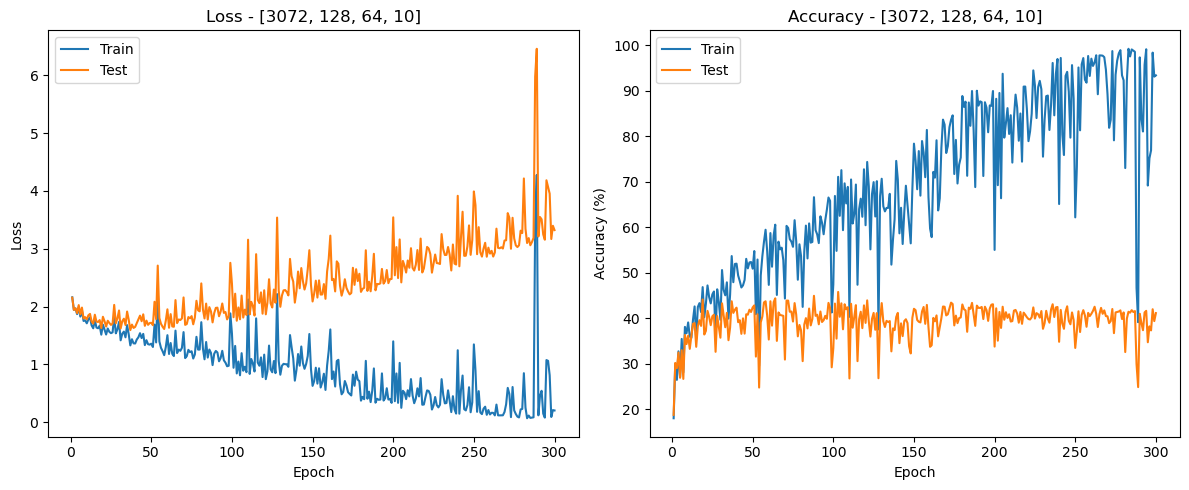


FINAL RESULTS
Final Train Accuracy: 93.36 %
Final Test Accuracy: 41.15 %


In [13]:
architecture1 = [
    3072,
    128,
    64,
    10
]

results1 = train_network(architecture1)



ARCHITECTURE: [3072, 256, 128, 64, 10]
Epoch: 1 | Train Loss: 2.2645 | Test Loss: 2.2809 | Train Acc: 21.82 | Test Acc: 21.45
Epoch: 2 | Train Loss: 2.0733 | Test Loss: 2.071 | Train Acc: 24.67 | Test Acc: 24.25
Epoch: 3 | Train Loss: 2.1332 | Test Loss: 2.148 | Train Acc: 22.42 | Test Acc: 23.55
Epoch: 4 | Train Loss: 2.1056 | Test Loss: 2.1331 | Train Acc: 25.73 | Test Acc: 25.25
Epoch: 5 | Train Loss: 1.8789 | Test Loss: 1.8956 | Train Acc: 33.65 | Test Acc: 33.65
Epoch: 6 | Train Loss: 1.8347 | Test Loss: 1.8645 | Train Acc: 33.43 | Test Acc: 33.15
Epoch: 7 | Train Loss: 1.7897 | Test Loss: 1.839 | Train Acc: 34.11 | Test Acc: 33.05
Epoch: 8 | Train Loss: 1.8705 | Test Loss: 1.9139 | Train Acc: 32.14 | Test Acc: 33.05
Epoch: 9 | Train Loss: 1.8574 | Test Loss: 1.9013 | Train Acc: 32.31 | Test Acc: 32.6
Epoch: 10 | Train Loss: 1.8252 | Test Loss: 1.8993 | Train Acc: 34.35 | Test Acc: 32.6
Epoch: 11 | Train Loss: 1.6542 | Test Loss: 1.7384 | Train Acc: 41.27 | Test Acc: 39.25
Epoch:

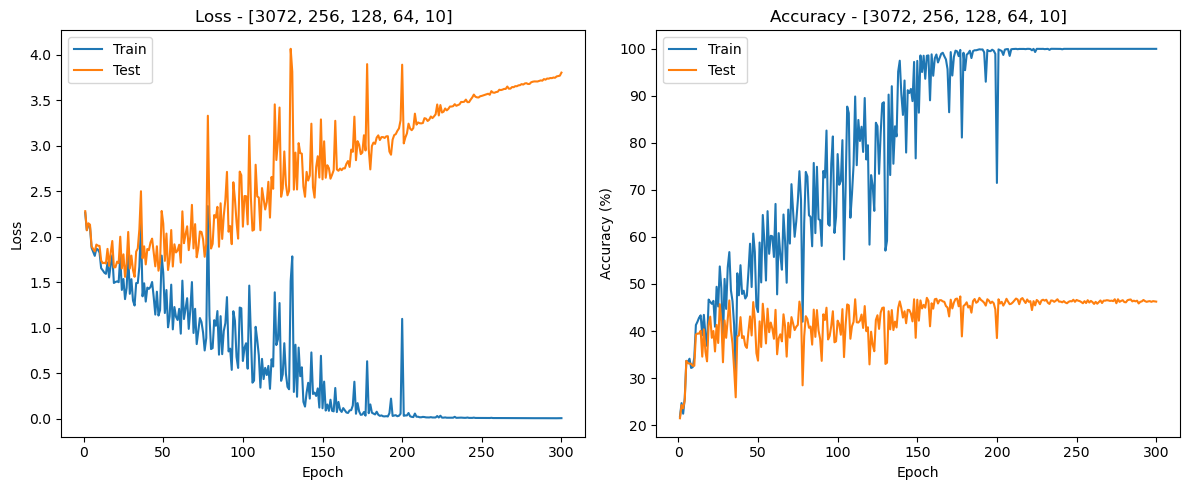


FINAL RESULTS
Final Train Accuracy: 99.99 %
Final Test Accuracy: 46.25 %


In [14]:
architecture2 = [
    3072,
    256,
    128,
    64,
    10
]

results2 = train_network(architecture2)


ARCHITECTURE: [3072, 512, 256, 128, 64, 10]
Epoch: 1 | Train Loss: 2.1717 | Test Loss: 2.2006 | Train Acc: 20.01 | Test Acc: 20.1
Epoch: 2 | Train Loss: 2.128 | Test Loss: 2.1732 | Train Acc: 24.43 | Test Acc: 24.25
Epoch: 3 | Train Loss: 1.8328 | Test Loss: 1.857 | Train Acc: 33.07 | Test Acc: 32.85
Epoch: 4 | Train Loss: 1.8362 | Test Loss: 1.881 | Train Acc: 34.91 | Test Acc: 32.85
Epoch: 5 | Train Loss: 1.7949 | Test Loss: 1.8555 | Train Acc: 36.47 | Test Acc: 35.2
Epoch: 6 | Train Loss: 1.7826 | Test Loss: 1.8505 | Train Acc: 36.88 | Test Acc: 35.7
Epoch: 7 | Train Loss: 1.713 | Test Loss: 1.7822 | Train Acc: 38.2 | Test Acc: 37.2
Epoch: 8 | Train Loss: 1.7011 | Test Loss: 1.7845 | Train Acc: 39.54 | Test Acc: 36.9
Epoch: 9 | Train Loss: 1.7272 | Test Loss: 1.8132 | Train Acc: 37.6 | Test Acc: 36.25
Epoch: 10 | Train Loss: 1.7405 | Test Loss: 1.8519 | Train Acc: 36.78 | Test Acc: 34.95
Epoch: 11 | Train Loss: 1.5708 | Test Loss: 1.6964 | Train Acc: 43.53 | Test Acc: 39.35
Epoch: 

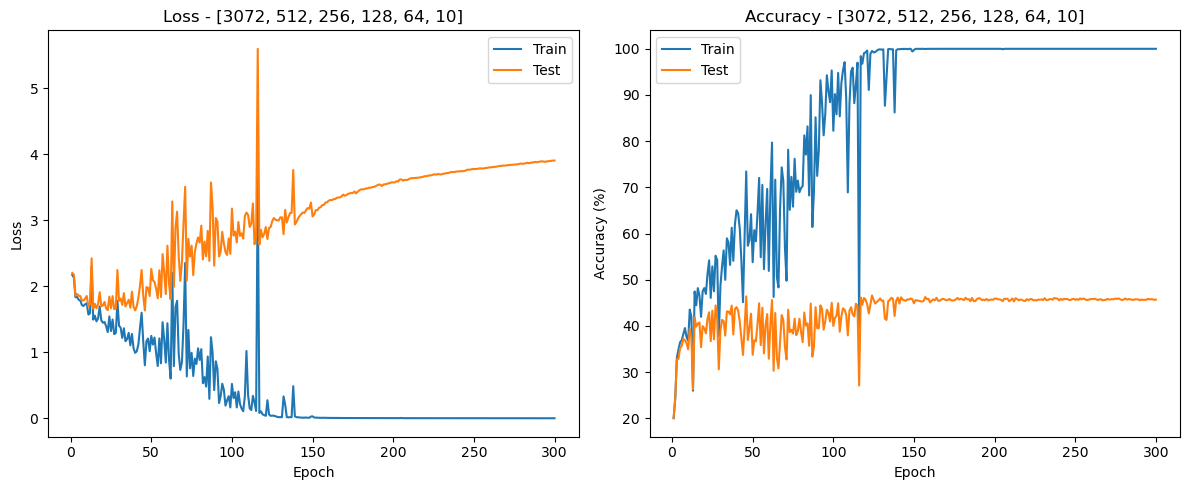


FINAL RESULTS
Final Train Accuracy: 100.0 %
Final Test Accuracy: 45.7 %


In [15]:
architecture3 = [
    3072,
    512,
    256,
    128,
    64,
    10
]

results3 = train_network(architecture3)


ARCHITECTURE: [3072, 64, 128, 256, 512, 10]
Epoch: 1 | Train Loss: 2.3424 | Test Loss: 2.3509 | Train Acc: 16.53 | Test Acc: 18.05
Epoch: 2 | Train Loss: 2.3638 | Test Loss: 2.3825 | Train Acc: 20.57 | Test Acc: 21.4
Epoch: 3 | Train Loss: 2.1146 | Test Loss: 2.1293 | Train Acc: 24.7 | Test Acc: 25.3
Epoch: 4 | Train Loss: 1.8524 | Test Loss: 1.8679 | Train Acc: 32.45 | Test Acc: 33.4
Epoch: 5 | Train Loss: 1.848 | Test Loss: 1.8831 | Train Acc: 34.06 | Test Acc: 33.7
Epoch: 6 | Train Loss: 1.8703 | Test Loss: 1.9135 | Train Acc: 32.92 | Test Acc: 32.35
Epoch: 7 | Train Loss: 1.7946 | Test Loss: 1.8327 | Train Acc: 35.83 | Test Acc: 35.3
Epoch: 8 | Train Loss: 1.9476 | Test Loss: 1.9856 | Train Acc: 32.92 | Test Acc: 33.6
Epoch: 9 | Train Loss: 1.9688 | Test Loss: 2.036 | Train Acc: 31.47 | Test Acc: 29.85
Epoch: 10 | Train Loss: 1.6784 | Test Loss: 1.7454 | Train Acc: 39.66 | Test Acc: 38.25
Epoch: 11 | Train Loss: 1.6083 | Test Loss: 1.7007 | Train Acc: 43.03 | Test Acc: 40.7
Epoch:

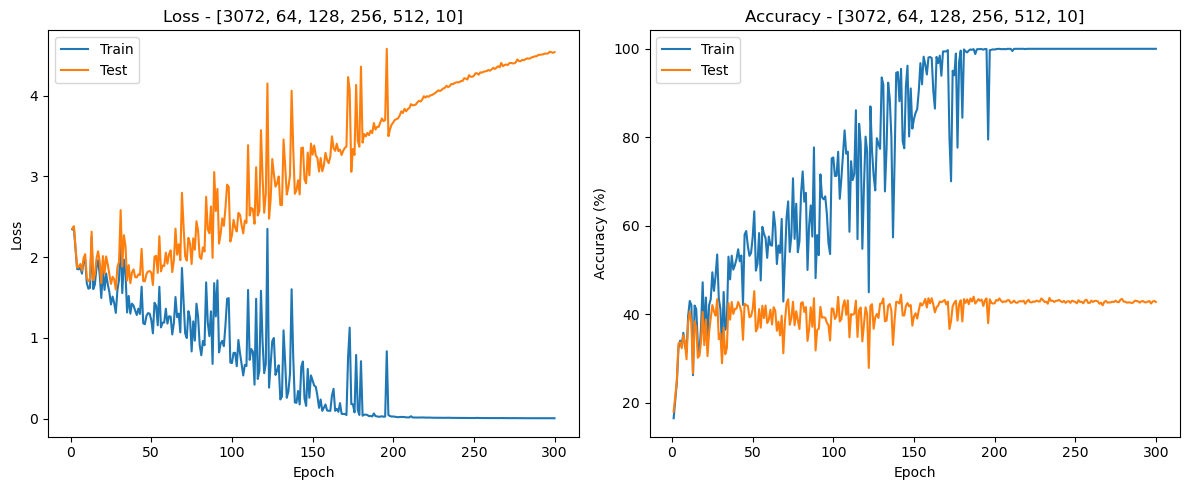


FINAL RESULTS
Final Train Accuracy: 100.0 %
Final Test Accuracy: 42.8 %


In [16]:
architecture4 = [
    3072,
    64,
    128,
    256,
    512,
    10
]

results4 = train_network(architecture4)


ARCHITECTURE: [3072, 128, 128, 128, 128, 10]
Epoch: 1 | Train Loss: 2.0894 | Test Loss: 2.0916 | Train Acc: 22.7 | Test Acc: 24.15
Epoch: 2 | Train Loss: 2.1146 | Test Loss: 2.1087 | Train Acc: 23.9 | Test Acc: 24.3
Epoch: 3 | Train Loss: 1.9976 | Test Loss: 2.017 | Train Acc: 28.92 | Test Acc: 28.4
Epoch: 4 | Train Loss: 1.8175 | Test Loss: 1.8335 | Train Acc: 33.89 | Test Acc: 34.75
Epoch: 5 | Train Loss: 1.9092 | Test Loss: 1.928 | Train Acc: 32.34 | Test Acc: 32.15
Epoch: 6 | Train Loss: 1.7157 | Test Loss: 1.7491 | Train Acc: 39.37 | Test Acc: 38.2
Epoch: 7 | Train Loss: 1.9505 | Test Loss: 1.9682 | Train Acc: 32.37 | Test Acc: 32.6
Epoch: 8 | Train Loss: 1.7077 | Test Loss: 1.7543 | Train Acc: 39.25 | Test Acc: 38.75
Epoch: 9 | Train Loss: 1.8448 | Test Loss: 1.9146 | Train Acc: 34.3 | Test Acc: 32.0
Epoch: 10 | Train Loss: 1.774 | Test Loss: 1.8454 | Train Acc: 36.86 | Test Acc: 35.1
Epoch: 11 | Train Loss: 1.7747 | Test Loss: 1.8411 | Train Acc: 33.43 | Test Acc: 32.15
Epoch: 

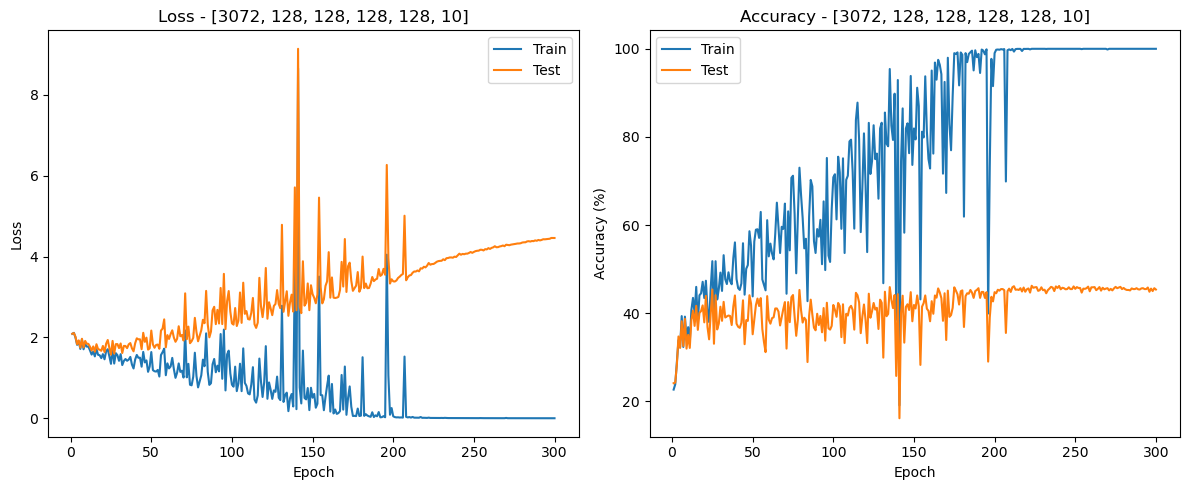


FINAL RESULTS
Final Train Accuracy: 100.0 %
Final Test Accuracy: 45.4 %


In [17]:
architecture5 = [
    3072,
    128,
    128,
    128,
    128,
    10
]

results5 = train_network(architecture5)


ARCHITECTURE: [3072, 64, 32, 16, 10]
Epoch: 1 | Train Loss: 2.1996 | Test Loss: 2.1922 | Train Acc: 19.09 | Test Acc: 19.25
Epoch: 2 | Train Loss: 2.1662 | Test Loss: 2.1699 | Train Acc: 21.22 | Test Acc: 22.1
Epoch: 3 | Train Loss: 2.2275 | Test Loss: 2.222 | Train Acc: 22.64 | Test Acc: 24.35
Epoch: 4 | Train Loss: 2.0681 | Test Loss: 2.0722 | Train Acc: 25.33 | Test Acc: 23.9
Epoch: 5 | Train Loss: 1.9915 | Test Loss: 2.0017 | Train Acc: 28.22 | Test Acc: 28.4
Epoch: 6 | Train Loss: 1.8352 | Test Loss: 1.8533 | Train Acc: 34.13 | Test Acc: 32.25
Epoch: 7 | Train Loss: 1.8535 | Test Loss: 1.8819 | Train Acc: 32.93 | Test Acc: 32.5
Epoch: 8 | Train Loss: 1.8638 | Test Loss: 1.9048 | Train Acc: 33.08 | Test Acc: 32.05
Epoch: 9 | Train Loss: 1.8078 | Test Loss: 1.8498 | Train Acc: 35.61 | Test Acc: 34.05
Epoch: 10 | Train Loss: 2.342 | Test Loss: 2.3884 | Train Acc: 23.65 | Test Acc: 24.45
Epoch: 11 | Train Loss: 2.021 | Test Loss: 2.0807 | Train Acc: 27.22 | Test Acc: 26.35
Epoch: 12 

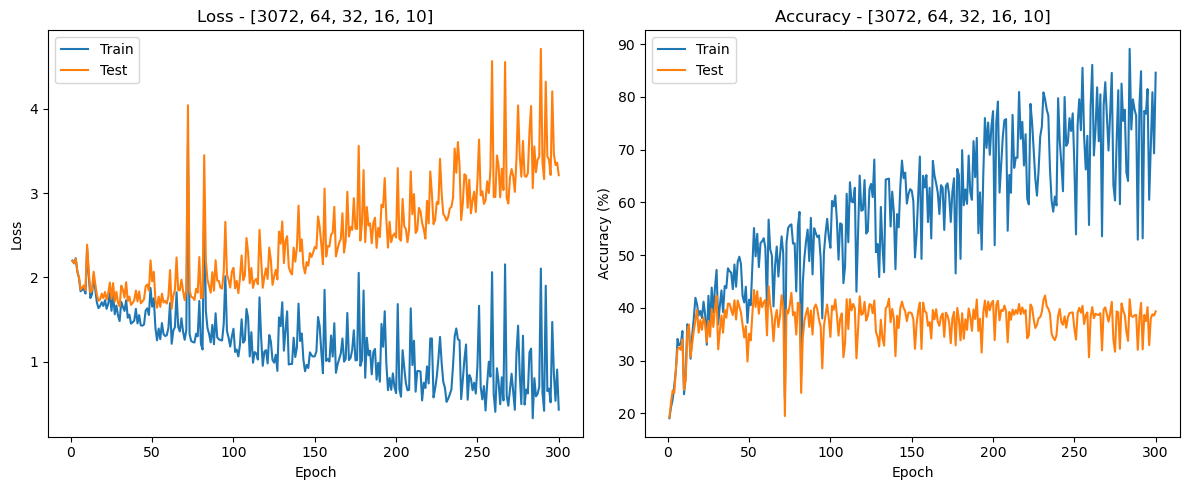


FINAL RESULTS
Final Train Accuracy: 84.58 %
Final Test Accuracy: 39.35 %


In [18]:
architecture6 = [
    3072,
    64,
    32,
    16,
    10
]

results6 = train_network(architecture6)


ARCHITECTURE: [3072, 80, 40, 20, 10]
Epoch: 1 | Train Loss: 2.2103 | Test Loss: 2.2191 | Train Acc: 15.02 | Test Acc: 12.7
Epoch: 2 | Train Loss: 2.3455 | Test Loss: 2.3518 | Train Acc: 19.5 | Test Acc: 19.9
Epoch: 3 | Train Loss: 2.0297 | Test Loss: 2.0332 | Train Acc: 22.71 | Test Acc: 22.95
Epoch: 4 | Train Loss: 2.2761 | Test Loss: 2.2942 | Train Acc: 18.84 | Test Acc: 17.95
Epoch: 5 | Train Loss: 2.3311 | Test Loss: 2.3351 | Train Acc: 20.08 | Test Acc: 21.1
Epoch: 6 | Train Loss: 1.8244 | Test Loss: 1.8429 | Train Acc: 33.41 | Test Acc: 33.0
Epoch: 7 | Train Loss: 1.7968 | Test Loss: 1.8203 | Train Acc: 35.18 | Test Acc: 34.55
Epoch: 8 | Train Loss: 1.8786 | Test Loss: 1.9094 | Train Acc: 30.69 | Test Acc: 30.4
Epoch: 9 | Train Loss: 1.8714 | Test Loss: 1.9065 | Train Acc: 32.9 | Test Acc: 30.95
Epoch: 10 | Train Loss: 1.8576 | Test Loss: 1.8942 | Train Acc: 33.61 | Test Acc: 33.25
Epoch: 11 | Train Loss: 1.8341 | Test Loss: 1.8806 | Train Acc: 32.85 | Test Acc: 30.7
Epoch: 12 |

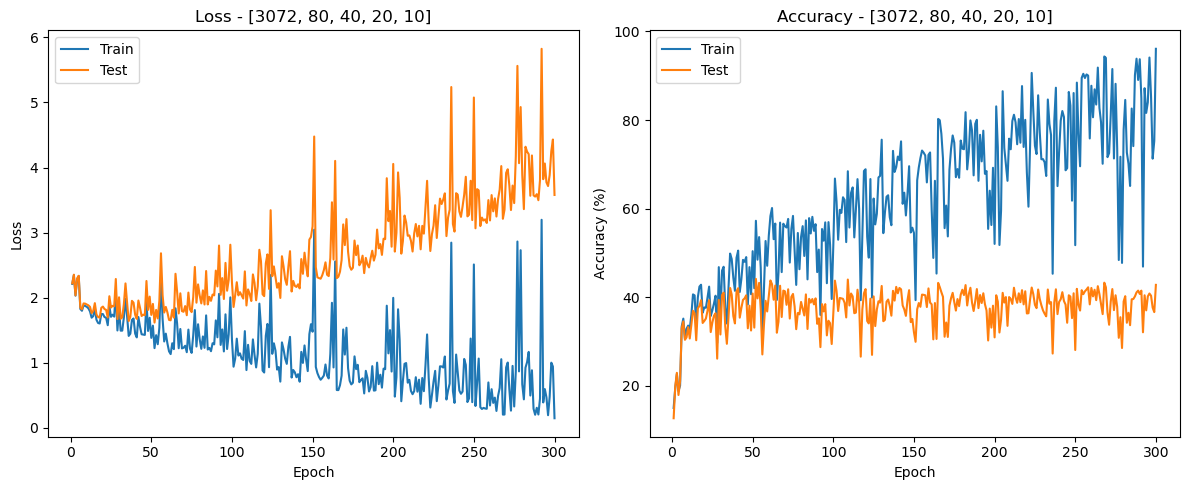


FINAL RESULTS
Final Train Accuracy: 96.07 %
Final Test Accuracy: 42.8 %


In [19]:
architecture7 = [
    3072,
    80,
    40,
    20,
    10
]

results7 = train_network(architecture7)


ARCHITECTURE: [3072, 16, 32, 64, 10]
Epoch: 1 | Train Loss: 2.2788 | Test Loss: 2.275 | Train Acc: 15.69 | Test Acc: 15.6
Epoch: 2 | Train Loss: 2.24 | Test Loss: 2.2278 | Train Acc: 19.5 | Test Acc: 19.2
Epoch: 3 | Train Loss: 2.169 | Test Loss: 2.1564 | Train Acc: 22.34 | Test Acc: 23.0
Epoch: 4 | Train Loss: 2.125 | Test Loss: 2.1152 | Train Acc: 22.74 | Test Acc: 22.4
Epoch: 5 | Train Loss: 2.0876 | Test Loss: 2.0743 | Train Acc: 25.23 | Test Acc: 24.95
Epoch: 6 | Train Loss: 2.0545 | Test Loss: 2.0367 | Train Acc: 24.23 | Test Acc: 24.95
Epoch: 7 | Train Loss: 2.0534 | Test Loss: 2.0534 | Train Acc: 24.61 | Test Acc: 24.85
Epoch: 8 | Train Loss: 1.9689 | Test Loss: 1.9599 | Train Acc: 26.81 | Test Acc: 28.25
Epoch: 9 | Train Loss: 1.9737 | Test Loss: 1.9614 | Train Acc: 27.24 | Test Acc: 28.1
Epoch: 10 | Train Loss: 1.9164 | Test Loss: 1.9122 | Train Acc: 30.45 | Test Acc: 30.2
Epoch: 11 | Train Loss: 1.9677 | Test Loss: 1.9652 | Train Acc: 27.32 | Test Acc: 29.1
Epoch: 12 | Trai

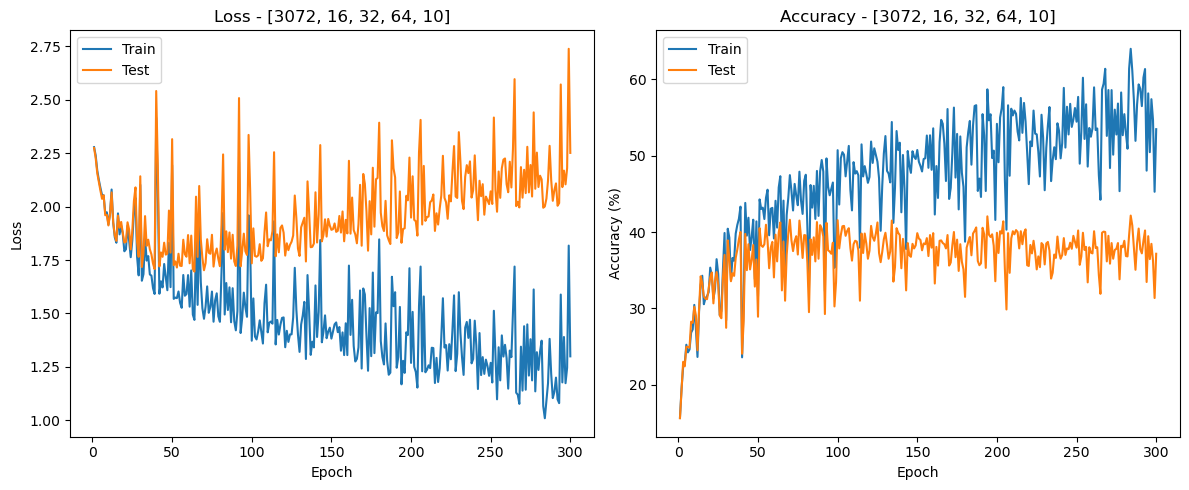


FINAL RESULTS
Final Train Accuracy: 53.47 %
Final Test Accuracy: 37.15 %


In [20]:
architecture8 = [
    3072,
    16,
    32,
    64,
    10
]

results8 = train_network(architecture8)


ARCHITECTURE: [3072, 8, 16, 32, 10]
Epoch: 1 | Train Loss: 2.2531 | Test Loss: 2.2533 | Train Acc: 15.64 | Test Acc: 15.95
Epoch: 2 | Train Loss: 2.239 | Test Loss: 2.2384 | Train Acc: 15.27 | Test Acc: 15.65
Epoch: 3 | Train Loss: 2.1003 | Test Loss: 2.0989 | Train Acc: 20.3 | Test Acc: 19.95
Epoch: 4 | Train Loss: 2.0392 | Test Loss: 2.0305 | Train Acc: 24.84 | Test Acc: 24.85
Epoch: 5 | Train Loss: 2.0226 | Test Loss: 2.0163 | Train Acc: 24.39 | Test Acc: 24.35
Epoch: 6 | Train Loss: 1.9992 | Test Loss: 2.0042 | Train Acc: 23.75 | Test Acc: 24.4
Epoch: 7 | Train Loss: 1.9525 | Test Loss: 1.9532 | Train Acc: 26.73 | Test Acc: 26.85
Epoch: 8 | Train Loss: 1.9547 | Test Loss: 1.9531 | Train Acc: 26.89 | Test Acc: 28.15
Epoch: 9 | Train Loss: 1.9803 | Test Loss: 1.9813 | Train Acc: 24.6 | Test Acc: 25.8
Epoch: 10 | Train Loss: 1.8957 | Test Loss: 1.9037 | Train Acc: 30.09 | Test Acc: 29.9
Epoch: 11 | Train Loss: 1.9303 | Test Loss: 1.9354 | Train Acc: 28.48 | Test Acc: 29.5
Epoch: 12 |

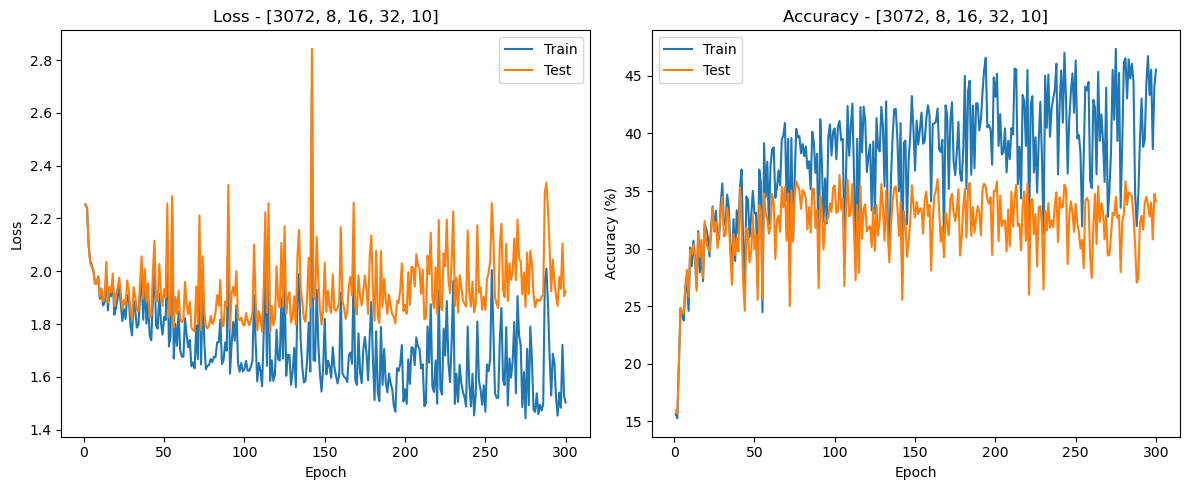


FINAL RESULTS
Final Train Accuracy: 45.55 %
Final Test Accuracy: 34.1 %


In [44]:
architecture9 = [
    3072,
    8,
    16,
    32,
    10
]

results9 = train_network(architecture9)


ARCHITECTURE: [3072, 32, 32, 32, 10]
Epoch: 1 | Train Loss: 2.1973 | Test Loss: 2.1868 | Train Acc: 19.05 | Test Acc: 19.1
Epoch: 2 | Train Loss: 2.1505 | Test Loss: 2.1453 | Train Acc: 23.81 | Test Acc: 23.85
Epoch: 3 | Train Loss: 2.0263 | Test Loss: 2.024 | Train Acc: 25.89 | Test Acc: 25.55
Epoch: 4 | Train Loss: 1.9459 | Test Loss: 1.9602 | Train Acc: 29.46 | Test Acc: 29.05
Epoch: 5 | Train Loss: 1.9678 | Test Loss: 1.9681 | Train Acc: 28.51 | Test Acc: 30.55
Epoch: 6 | Train Loss: 1.9114 | Test Loss: 1.9181 | Train Acc: 29.8 | Test Acc: 29.0
Epoch: 7 | Train Loss: 1.8533 | Test Loss: 1.8673 | Train Acc: 32.96 | Test Acc: 32.05
Epoch: 8 | Train Loss: 2.0753 | Test Loss: 2.1121 | Train Acc: 25.84 | Test Acc: 25.45
Epoch: 9 | Train Loss: 2.0545 | Test Loss: 2.0936 | Train Acc: 27.1 | Test Acc: 27.5
Epoch: 10 | Train Loss: 1.9672 | Test Loss: 2.0072 | Train Acc: 29.55 | Test Acc: 28.3
Epoch: 11 | Train Loss: 1.8294 | Test Loss: 1.8496 | Train Acc: 33.86 | Test Acc: 33.9
Epoch: 12 |

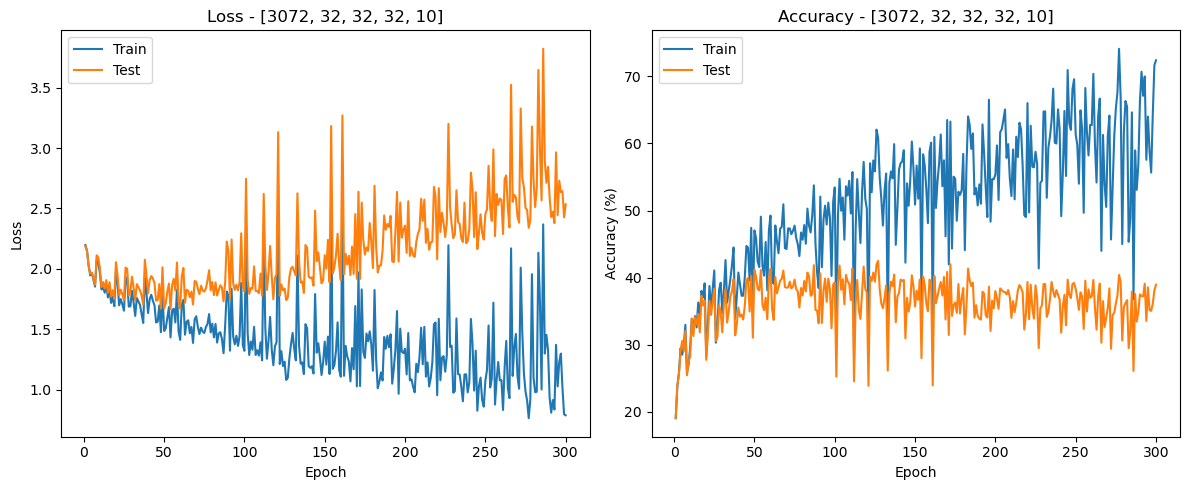


FINAL RESULTS
Final Train Accuracy: 72.38 %
Final Test Accuracy: 38.95 %


In [45]:
architecture10 = [
    3072,
    32,
    32,
    32,
    10
]

results10 = train_network(architecture10)

In [48]:

# ============================================================
# PORÓWNANIE ARCHITEKTUR
# ============================================================

print("\n===================================")

print("ARCHITECTURE COMPARISON")

print("===================================")

print(

    architecture1,
    "| Test Accuracy:",
    round(
        results1["final_test_accuracy"],
        2
    ),
    "%"

)

print(

    architecture2,
    "| Test Accuracy:",
    round(
        results2["final_test_accuracy"],
        2
    ),
    "%"

)

print(

    architecture3,
    "| Test Accuracy:",
    round(
        results3["final_test_accuracy"],
        2
    ),
    "%"

)
print(

    architecture4,
    "| Test Accuracy:",
    round(
        results4["final_test_accuracy"],
        2
    ),
    "%"

)
print(

    architecture5,
    "| Test Accuracy:",
    round(
        results5["final_test_accuracy"],
        2
    ),
    "%"

)
print(

    architecture6,
    "| Test Accuracy:",
    round(
        results6["final_test_accuracy"],
        2
    ),
    "%"

)
print(

    architecture7,
    "| Test Accuracy:",
    round(
        results7["final_test_accuracy"],
        2
    ),
    "%"

)
print(

    architecture8,
    "| Test Accuracy:",
    round(
        results8["final_test_accuracy"],
        2
    ),
    "%"

)
print(

    architecture9,
    "| Test Accuracy:",
    round(
        results9["final_test_accuracy"],
        2
    ),
    "%"

)
print(

    architecture10,
    "| Test Accuracy:",
    round(
        results10["final_test_accuracy"],
        2
    ),
    "%"

)


ARCHITECTURE COMPARISON
[3072, 128, 64, 10] | Test Accuracy: 41.15 %
[3072, 256, 128, 64, 10] | Test Accuracy: 46.25 %
[3072, 512, 256, 128, 64, 10] | Test Accuracy: 45.7 %
[3072, 64, 128, 256, 512, 10] | Test Accuracy: 42.8 %
[3072, 128, 128, 128, 128, 10] | Test Accuracy: 45.4 %
[3072, 64, 32, 16, 10] | Test Accuracy: 39.35 %
[3072, 80, 40, 20, 10] | Test Accuracy: 42.8 %
[3072, 16, 32, 64, 10] | Test Accuracy: 37.15 %
[3072, 8, 16, 32, 10] | Test Accuracy: 34.1 %
[3072, 32, 32, 32, 10] | Test Accuracy: 38.95 %
